## House Price Prediction
California Housing Dataset Overview
This dataset contains information collected from the 1990 California Census. It is commonly used to practice regression problems, where the goal is to predict the median house value for a specific district (block group).

Location Features
Longitude: A measure of how far west a house is; a higher value is farther west.

Latitude: A measure of how far north a house is; a higher value is farther north.

Ocean Proximity: The ocean_proximity feature is a categorical variable that represents the location of the housing block relative to the ocean. This is often one of the most influential features in predicting house values in California.

## Khám phá dữ liệu

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

In [ ]:
df = pd.read_csv('data/housing.csv')
print('Kích thước:', df.shape)
df.head()

Kích thước: (20640, 10)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


In [ ]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [ ]:
df.isnull().sum()


longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

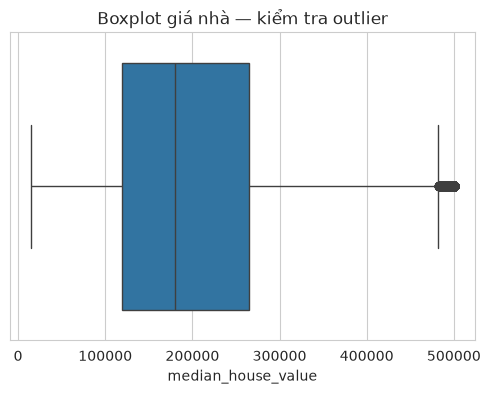

Số dòng giá bị capped ở 500001: 965


In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['median_house_value'])
plt.title('Boxplot giá nhà — kiểm tra outlier')
plt.show()

print('Số dòng giá bị capped ở 500001:', (df['median_house_value'] == 500001).sum())

In [ ]:
df = df[df['median_house_value'] < 500001].copy()
print('Kích thước sau khi loại outlier:', df.shape)

Kích thước sau khi loại outlier: (19675, 10)


In [ ]:
df['rooms_per_household'] = df['total_rooms'] / df['households']
df['bedrooms_per_room'] = df['total_bedrooms'] / df['total_rooms']
df['population_per_household'] = df['population'] / df['households']

df[['rooms_per_household', 'bedrooms_per_room', 'population_per_household']].describe()

,rooms_per_household,bedrooms_per_room,population_per_household
count,19675.000000,19475.000000,19675.000000
mean,5.360901,0.214975,3.095189
std,2.292538,0.056937,10.631977
min,0.846154,0.100000,0.692308
25%,4.414568,0.177655,2.445486
50%,5.184322,0.204583,2.837134
75%,5.970677,0.240950,3.304894
max,132.533333,1.000000,1243.333333


In [ ]:
numeric_features = ['longitude', 'latitude', 'housing_median_age', 'total_rooms','total_bedrooms', 'population', 'households', 'median_income','rooms_per_household', 'bedrooms_per_room','population_per_household']
categorical_features = ['ocean_proximity']

X = df[numeric_features + categorical_features]
y = df['median_house_value']
X.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,rooms_per_household,bedrooms_per_room,population_per_household,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,6.984127,0.146591,2.555556,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,6.238137,0.155797,2.109842,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,8.288136,0.129516,2.802260,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,5.817352,0.184458,2.547945,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,6.281853,0.172096,2.181467,NEAR BAY


In [ ]:
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline([
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, numeric_features),
    ('cat', categorical_pipeline, categorical_features)
])

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print('Train:', X_train.shape, '| Test:', X_test.shape)

Train: (15740, 12) | Test: (3935, 12)


In [ ]:
lin_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

lin_pipeline.fit(X_train, y_train)
print('Đã huấn luyện xong.')

Đã huấn luyện xong.


In [ ]:
def evaluate(model, X_test, y_test, name='Model'):
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    print(f'--- {name} ---')
    print(f'MSE  : {mse:,.2f}')
    print(f'RMSE : {rmse:,.2f}')
    print(f'MAE  : {mae:,.2f}')
    print(f'R^2  : {r2:.4f}')
    return y_pred

y_pred_lin = evaluate(lin_pipeline, X_test, y_test, 'Linear Regression')

--- Linear Regression ---
MSE  : 3,827,141,429.09
RMSE : 61,863.89
MAE  : 45,199.37
R^2  : 0.6162


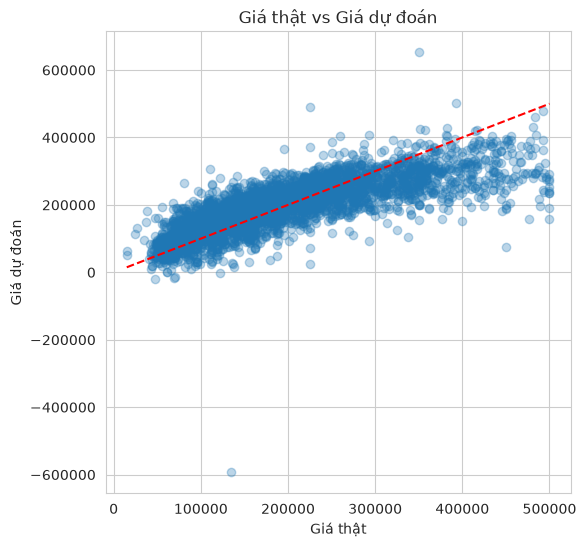

In [ ]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_lin, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Giá thật')
plt.ylabel('Giá dự đoán')
plt.title('Giá thật vs Giá dự đoán')
plt.show()

## 5. Tinh chỉnh mô hình
`LinearRegression` thuần không có hệ số `alpha`. Alpha là tham số điều chỉnh (regularization strength), chỉ có ở **Ridge** (L2) và **Lasso** (L1). Ta thử cả hai, dò alpha bằng `GridSearchCV`.

In [ ]:
alphas = {'model__alpha': [0.01, 0.1, 1, 10, 50, 100, 200, 500]}

ridge_pipeline = Pipeline([('preprocessor', preprocessor), ('model', Ridge())])
ridge_grid = GridSearchCV(ridge_pipeline, alphas, cv=5, scoring='neg_root_mean_squared_error')
ridge_grid.fit(X_train, y_train)
print('Ridge best alpha:', ridge_grid.best_params_)

lasso_pipeline = Pipeline([('preprocessor', preprocessor), ('model', Lasso(max_iter=10000))])
lasso_grid = GridSearchCV(lasso_pipeline, alphas, cv=5, scoring='neg_root_mean_squared_error')
lasso_grid.fit(X_train, y_train)
print('Lasso best alpha:', lasso_grid.best_params_)

Ridge best alpha: {'model__alpha': 0.01}


/home/whyh/projects/house-price-prediction/venv/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.705480e+12, tolerance: 1.186e+10
  model = cd_fast.enet_coordinate_descent(
/home/whyh/projects/house-price-prediction/venv/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.742870e+12, tolerance: 1.194e+10
  model = cd_fast.enet_coordinate_descent(
/home/whyh/projects/house-price-prediction/venv/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterati

Lasso best alpha: {'model__alpha': 0.01}


/home/whyh/projects/house-price-prediction/venv/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.654016e+12, tolerance: 1.486e+10
  model = cd_fast.enet_coordinate_descent(


In [ ]:
best_ridge = ridge_grid.best_estimator_
best_lasso = lasso_grid.best_estimator_

_ = evaluate(lin_pipeline, X_test, y_test, 'Linear Regression')
_ = evaluate(best_ridge, X_test, y_test, f"Ridge (alpha={ridge_grid.best_params_['model__alpha']})")
_ = evaluate(best_lasso, X_test, y_test, f"Lasso (alpha={lasso_grid.best_params_['model__alpha']})")

--- Linear Regression ---
MSE  : 3,827,141,429.09
RMSE : 61,863.89
MAE  : 45,199.37
R^2  : 0.6162
--- Ridge (alpha=0.01) ---
MSE  : 3,827,121,619.35
RMSE : 61,863.73
MAE  : 45,199.30
R^2  : 0.6162
--- Lasso (alpha=0.01) ---
MSE  : 3,827,139,152.80
RMSE : 61,863.88
MAE  : 45,199.37
R^2  : 0.6162


In [ ]:
new_houses = pd.DataFrame([
    {'longitude': -122.25, 'latitude': 37.85, 'housing_median_age': 30,
     'total_rooms': 2000, 'total_bedrooms': 400, 'population': 900,
     'households': 350, 'median_income': 5.5,
     'rooms_per_household': 2000/350, 'bedrooms_per_room': 400/2000,
     'population_per_household': 900/350, 'ocean_proximity': 'NEAR BAY'},
])[numeric_features + categorical_features]

predicted = lin_pipeline.predict(new_houses)
print('Giá dự đoán:', round(predicted[0], 0), 'USD')

Giá dự đoán: 286257.0 USD


## Nhận xét kết quả

So sánh 3 mô hình trên tập test:

| Mô hình | RMSE | R² |
|---|---|---|
| Linear Regression | 61,863.89 | 0.6162 |
| Ridge (alpha=0.01) | 61,863.73 | 0.6162 |
| Lasso (alpha=0.01) | 61,863.88 | 0.6162 |

- Alpha tối ưu tìm được qua GridSearchCV đều rất nhỏ (0.01), gần với 0 — nghĩa là mức phạt regularization gần như không tác động, Ridge/Lasso gần tương đương Linear Regression thuần.
- Ridge và Lasso không cải thiện đáng kể so với baseline (chênh lệch RMSE < 1 đồng). Điều này cho thấy dữ liệu **không bị đa cộng tuyến (multicollinearity) nghiêm trọng** — nếu có, regularization sẽ giúp giảm RMSE rõ rệt hơn.
- R² = 0.6162 nghĩa là mô hình giải thích được ~61.6% biến thiên của giá nhà — mức khá cho baseline Linear Regression, các sai số còn lại (RMSE ~61,864 USD) có thể do quan hệ phi tuyến giữa đặc trưng và giá nhà mà Linear Regression không nắm bắt được (cần mô hình phi tuyến như Random Forest/Gradient Boosting để cải thiện thêm — ngoài phạm vi bài này).
- **Mô hình được chọn: Ridge (alpha=0.01)** — RMSE thấp nhất trên test set, dù chênh lệch không đáng kể so với Linear Regression.